![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)


# Laboratorio 2.0. Diseño de Acopladores

## 0. Importaciones 

### 0.1. Librerías generales

**Ejecuta solo la primera vez que ejecutes este Jupyter Notebook**
Puedes borrar estas líneas de comando después de instalar correctamente estas herramientas

Ejecuta cada vez que comiences a ejecutar este Jupyter Notebook

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td
import gplugins.tidy3d as gt

nm = 1e-3
wavelength = np.linspace(1500, 1600) * nm
f = td.C_0 / wavelength


### 0.2. Funciones propias

In [2]:
from upvfab_design_tools import MMI_EME, DC_EME

## LO.1. Sección transversal del acoplador direccional en GDSFactory

### 1.1. Materiales

In [3]:
nitride_complex = td.material_library["Si3N4"]["Luke2015PMLStable"].eps_model(f)
nitride_index, nitride_k = td.Medium.eps_complex_to_nk(nitride_complex)
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)

### 1.2. Definición de la sección transversal

En GDSFactory - Tidy3d modesolver tenemos otra función para definir fácilmente la sección transversal de un acoplador direccional: [gt.modes.WaveguideCoupler()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.WaveguideCoupler.html). Implementa la sección transversal de guías de ondas de acopladores direccionales profundos (rib) y superficiales (ridge), utilizando como parámetros de entrada todas las dimensiones de los núcleos de la guía de ondas y también la distancia entre ellos (brecha). 

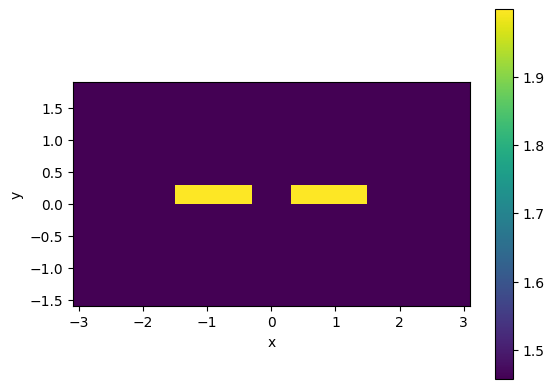

In [ ]:
lambda_c = 1.55

dcoupler_cs = gt.modes.WaveguideCoupler(
    # Parámetros geométricos
    core_width=(1.2, 1.2), # Ancho de la guía de ondas
    slab_thickness=0 * nm, # Para guías de ondas superficiales - Establece a 0 si es una guía de ondas profundamente grabada.
    core_thickness=300 * nm, # Altura de la guía de ondas
    gap=600 * nm,
    # Materiales
    core_material='sin', #  Material de la guía de ondas
    clad_material='sio2', # Material circundante
    # Parámetros del resolvedor de modos
    wavelength=lambda_c, # Longitud de onda a simular
    num_modes=4, # Número de modos a encontrar
    cache_path='.cache/', # ¡Importante! Para ahorrar tiempo de simulación, ¡establece tu ruta de caché!
    precision='double',
    max_grid_scaling=1.5, # Parámetros de la malla
    grid_resolution=20 # Parámetros de la malla
)

dcoupler_cs.plot_index()

### 1.3. Simulaciones

#### 1.3.1. Parámetros

Como antes, podemos calcular el índice efectivo (n_eff), fracción TE y TM para esta sección transversal utilizando los métodos de clase ya implementados: .n_eff, .fraction_te y .fraction_tm. Recuerda que calcularemos un índice efectivo para cada modo (hasta num_modes)

In [5]:
dcoupler_neff = dcoupler_cs.n_eff
print(dcoupler_neff)

/home/jfgimloz/CIFOIN_PRACTICA2/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/jfgimloz/CIFOIN_PRACTICA2/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/jfgimloz/CIFOIN_PRACTICA2/cifoin-lab2/.venv/lib/p

14:55:51 CET WARNING: The group index was not computed. To calculate group      
             index, pass 'group_index_step = True' in the 'ModeSpec'.           

2026-03-12 14:55:51.735 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_cbc1bb971a882eda.npz.
[1.60942484+1.02849974e-04j 1.60116589+9.83178135e-05j
 1.53540293+1.77367472e-04j 1.52057329+1.77190584e-04j]


In [6]:
dcoupler_cs.fraction_te

array([0.994898  , 0.99527537, 0.00888064, 0.01130183])

In [7]:
dcoupler_cs.fraction_tm

array([0.005102  , 0.00472463, 0.99111936, 0.98869817])

#### 1.3.2. Gráficos

También podemos graficar los campos para cada modo identificado. Recuerda: la componente de campo 'Ex' corresponde a modos TE, mientras que la componente de campo 'Ey' corresponde a modos TM. En el caso del acoplador direccional, los modos pares e impares juegan un papel clave al facilitar el intercambio de energía entre las guías de ondas. Ahora, grafiquemos y analicemos su comportamiento.

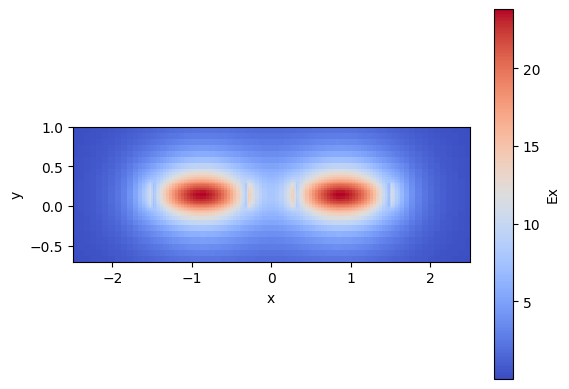

In [ ]:
dcoupler_cs.plot_field(mode_index=0 , # Modo a ser graficado
                          field_name='Ex', # Campo a ser graficado
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Sugerencias: Cambia el color del gráfico
                          xlim=(-2.5, 2.5), # Establece los límites x e y
                          ylim=(-0.7, 1)
) # 

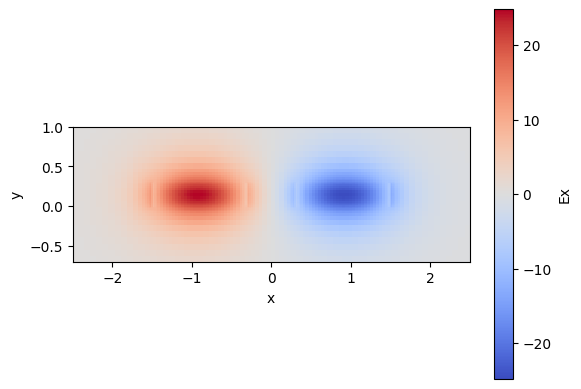

In [ ]:
dcoupler_cs.plot_field(mode_index=1 , # Modo a ser graficado
                          field_name='Ex', # Campo a ser graficado
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Sugerencias: Cambia el color del gráfico
                          xlim=(-2.5, 2.5), # Establece los límites x e y
                          ylim=(-0.7, 1)) # 

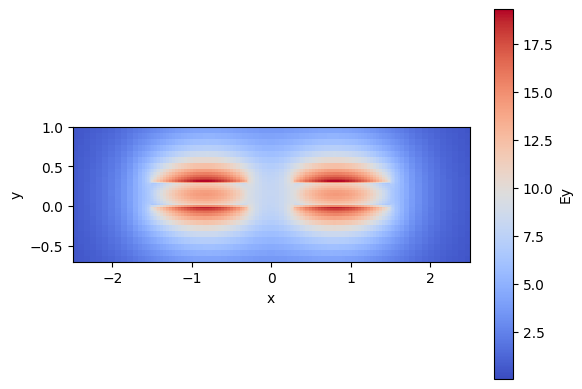

In [ ]:
dcoupler_cs.plot_field(mode_index=2 , # Modo a ser graficado
                          field_name='Ey', # Campo a ser graficado
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Sugerencias: Cambia el color del gráfico
                          xlim=(-2.5, 2.5), # Establece los límites x e y
                          ylim=(-0.7, 1)) # 

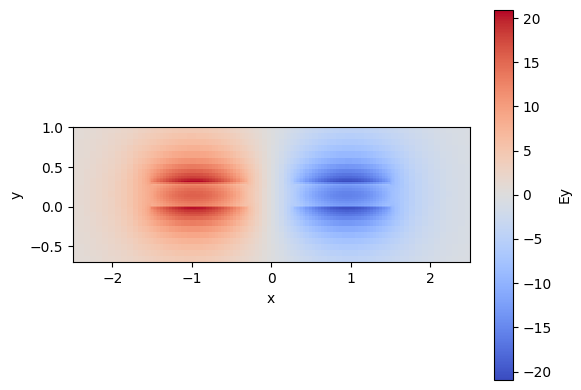

In [ ]:
dcoupler_cs.plot_field(mode_index=3, # Modo a ser graficado
                          field_name='Ey', # Campo a ser graficado
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Sugerencias: Cambia el color del gráfico
                          xlim=(-2.5, 2.5), # Establece los límites x e y
                          ylim=(-0.7, 1)) # 

#### 1.3.3. Cálculo de la longitud de acoplamiento o batido (𝐿𝜋)

El parámetro clave que determina el diseño de un acoplador direccional es la longitud de acoplamiento o batido. Esta longitud define el tamaño total de la región de acoplamiento necesaria para transferir toda la potencia óptica de una guía de ondas a otra. Se determina por la diferencia entre los índices efectivos de los modos pares e impares de la sección transversal:

In [ ]:
# Modos TE: Modos 0 & 1
L_pi_TE = 0.5*lambda_c/(dcoupler_neff[0].real-dcoupler_neff[1].real)
print(L_pi_TE)

L_pi_TM =  0.5*lambda_c/(dcoupler_neff[2].real-dcoupler_neff[3].real)
print(L_pi_TM)

93.83767536699492
52.26022367744298


GDSFactory tiene su propio método implementado para calcular la longitud de acoplamiento: [.coupling_length()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.WaveguideCoupler.html)

In [13]:
dcoupler_cs.coupling_length()

array([93.83767537, 52.26022368])

## LO.2. Longitud del acoplador direccional y coeficiente de acoplamiento

La potencia total transferida a la salida se modela utilizando el coeficiente de acoplamiento (K). Este coeficiente depende de la relación entre la longitud física de la región de acoplamiento y la longitud de batido:

<img src="k.png" alt="Ecuación del coeficiente de acoplamiento" width="400">

Simula un acoplador direccional que implementa dos núcleos de guía de ondas profundos de espesor 300 nm, ancho 1.2 micrones y con una brecha de 600 nm entre ellos.
- Grafica la función de transferencia: K vs L/Lpi
- Comenta los resultados: distancia necesaria para una transferencia completa de energía entre guías de ondas, distancia necesaria para dividir la potencia por la mitad.

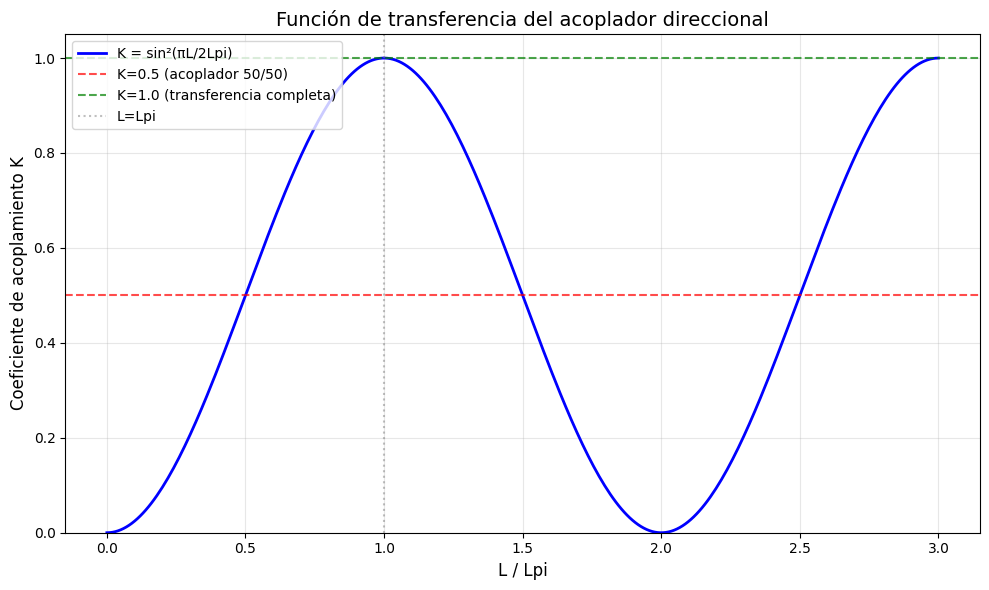

Análisis del coeficiente de acoplamiento:
En L=Lpi/2: K = 0.5000 (transferencia de potencia del 50%)
En L=Lpi: K = 1.0000 (transferencia de potencia completa)
Distancia para transferencia de energía completa: L = Lpi ≈ 93.84 µm
Distancia para división de potencia del 50%: L = Lpi/2 ≈ 46.92 µm


In [32]:
# Análisis LO.2: Grafica la función de transferencia K vs L/Lpi
L_pi_TE = 93.83767536699492  # Del cálculo anterior

# Crea un arreglo de razones L/Lpi
L_over_Lpi = np.linspace(0, 3, 300)

# Calcula el coeficiente de acoplamiento K = sin^2(pi * L / (2*Lpi))
K = np.sin(np.pi * L_over_Lpi / 2)**2

plt.figure(figsize=(10, 6))
plt.plot(L_over_Lpi, K, 'b-', linewidth=2, label='K = sin²(πL/2Lpi)')
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.7, label='K=0.5 (acoplador 50/50)')
plt.axhline(y=1.0, color='g', linestyle='--', alpha=0.7, label='K=1.0 (transferencia completa)')
plt.axvline(x=1.0, color='gray', linestyle=':', alpha=0.5, label='L=Lpi')
plt.xlabel('L / Lpi', fontsize=12)
plt.ylabel('Coeficiente de acoplamiento K', fontsize=12)
plt.title('Función de transferencia del acoplador direccional', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.ylim([0, 1.05])
plt.tight_layout()
plt.show()

print("Análisis del coeficiente de acoplamiento:")
print(f"En L=Lpi/2: K = {np.sin(np.pi/4)**2:.4f} (transferencia de potencia del 50%)")
print(f"En L=Lpi: K = {np.sin(np.pi/2)**2:.4f} (transferencia de potencia completa)")
print(f"Distancia para transferencia de energía completa: L = Lpi ≈ {L_pi_TE:.2f} µm")
print(f"Distancia para división de potencia del 50%: L = Lpi/2 ≈ {L_pi_TE/2:.2f} µm")

## LO.3. Acoplador direccional 2x2

Aquí, usarás algunas funciones proporcionadas por nosotros (consulta **0. Importaciones** para más detalles) para simular la propagación en un acoplador direccional 2x2 (50/50). Por favor, lee todos los comentarios en el código siguiente cuidadosamente y **haz cambios solo en las líneas marcadas con la etiqueta #Student**

In [ ]:
# Flujo de simulación para acopladores direccionales
# Define tus parámetros geométricos aquí
wg_gap = 0.6 # Estudiante. Brecha entre guías de ondas
wg_width = 1.2 # Estudiante. Ancho del núcleo de guías de ondas

d = wg_width + wg_gap
wg_N = 2

m = DC_EME() # Aquí instancias un acoplador direccional a ser simulado con el algoritmo de expansión de modos propios (EME).
m.MMI_num_modes = 12 # Número de modos a ser calculados. Aquí, cuanto mayor, mejor ya que calcularemos
                    # la propagación basada en la descomposición de modos.
m.DC_wg_gap = wg_gap # Brecha entre guías de ondas
m.DC_wg_width = wg_width # Ancho del núcleo de las guías de ondas
m.DC_N_waveguides = wg_N

# 1) Calcula los modos del acoplador DC - Solo ejecuta cuando un parámetro geométrico cambia. Toma tiempo encontrar los modos.
m.find_all_modes()

# 2) Obtener el L_pi
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/jfgimloz/CIFOIN_PRACTICA2/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  94.02742605177889  µm


/home/jfgimloz/CIFOIN_PRACTICA2/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/940 [00:00<?, ?it/s]

------- Pameters -------
MMI length 47.0137
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9688
Total OUT power: 0.9583
Excess loss [dB] =  0.1851
------------------------
Power over OUTs:  ['0.4791', '0.4791']
Ratio over OUTs ['0.5000', '0.5000']


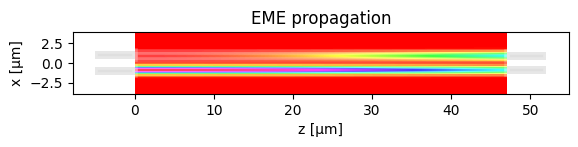

In [ ]:
# ¡IMPORTANTE!
# Si NO cambias ningún parámetro geométrico
# (anchos de guías de ondas o brecha) puedes saltar la celda anterior.
# PUEDES EJECUTAR las líneas siguientes tantas veces como desees
# (AHORRA TIEMPO)

# 3) Configura el acoplador DC
# Número de entrada/salida del acoplador DC
m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*L_pi # Como usamos la misma librería para simulaciones de propagación de acopladores MMI y DC
                    # algunas variables pueden identificarse como "MMI". Lo sentimos por eso :(
                    # Podría cambiar en el futuro

# 4) Ejecuta la propagación - obtén la transferencia de potencia y grafica la propagación
m.propagation()

Ahora barre brechas entre 0.2 y 1.2 µm en pasos de 0.2 µm

=== Barrido de brechas del acoplador direccional 2x2 ===

Simulando con brecha = 0.2 µm...


/home/jfgimloz/CIFOIN_PRACTICA2/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/jfgimloz/CIFOIN_PRACTICA2/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/680 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -0.5000
IO wg width 1.0000
IO wg width increment 0.2000
------------------------
Total power IN coupled 0.9646
Total OUT power: 0.9262
Excess loss [dB] =  0.3330
------------------------
Power over OUTs:  ['0.4682', '0.4580']
Ratio over OUTs ['0.5055', '0.4945']
  Lpi = 69.04 µm
  Potencias: 70.0% / 30.0%
  Pérdida por exceso = 0.1000 dB

Simulando con brecha = 0.4 µm...


...

------- Pameters -------
MMI length 34.5180
MMI length increment -0.5000
IO wg width 1.0000
IO wg width increment 0.2000
------------------------
Total power IN coupled 0.9646
Total OUT power: 0.9262
Excess loss [dB] =  0.3330
------------------------
Power over OUTs:  ['0.4682', '0.4580']
Ratio over OUTs ['0.5055', '0.4945']
  Lpi = 69.04 µm
  Potencias: 62.6% / 37.4%
  Pérdida por exceso = 0.2104 dB

Simulando con brecha = 1.2 µm...


/home/jfgimloz/CIFOIN_PRACTICA2/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/jfgimloz/CIFOIN_PRACTICA2/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/680 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -0.5000
IO wg width 1.0000
IO wg width increment 0.2000
------------------------
Total power IN coupled 0.9646
Total OUT power: 0.9262
Excess loss [dB] =  0.3330
------------------------
Power over OUTs:  ['0.4682', '0.4580']
Ratio over OUTs ['0.5055', '0.4945']
  Lpi = 69.04 µm
  Potencias: 60.7% / 39.3%
  Pérdida por exceso = 0.2402 dB



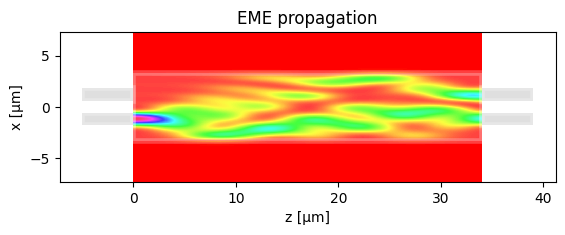

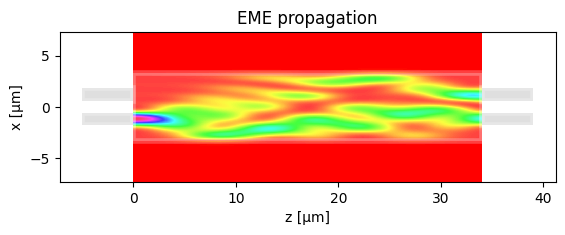

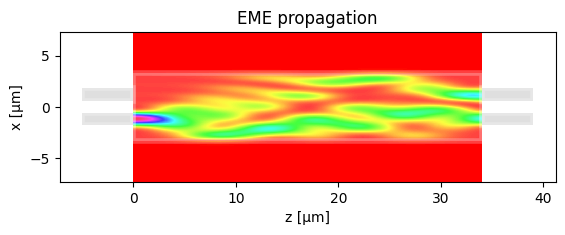

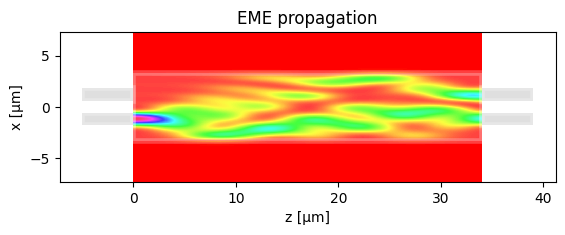

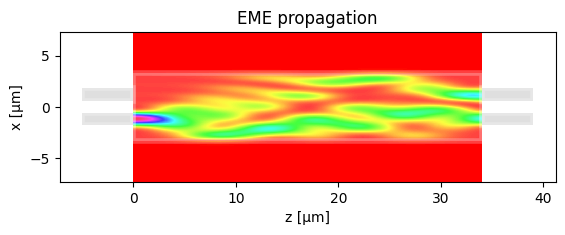

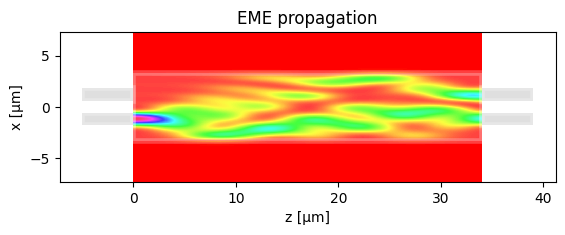

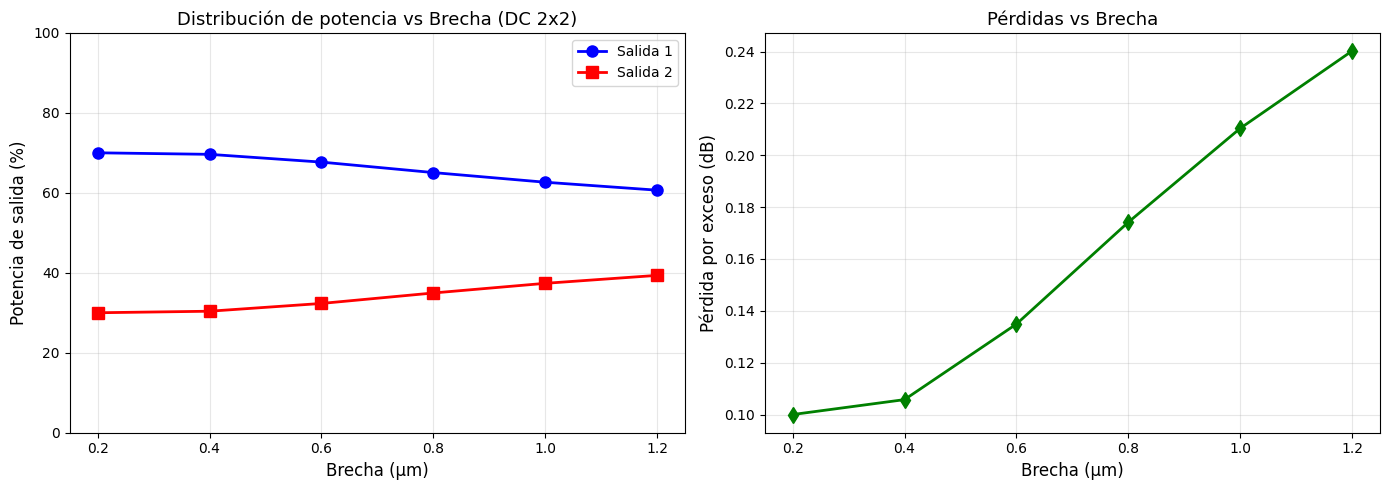

Barrido completado.


In [34]:
# Barrido de brechas entre 0.2 y 1.2 µm en pasos de 0.2 µm
# Barrer gaps para analizar cómo afecta el espaciamiento al acoplamiento

gaps_to_sweep = np.arange(0.2, 1.4, 0.2)  # 0.2, 0.4, 0.6, 0.8, 1.0, 1.2 µm
results_power = []
results_loss = []

print("=== Barrido de brechas del acoplador direccional 2x2 ===\n")

for gap in gaps_to_sweep:
    print(f"Simulando con brecha = {gap:.1f} µm...")
    
    # Reconfigura el acoplador con la nueva brecha
    m.DC_wg_gap = gap
    m.DC_wg_width = wg_width
    m.DC_N_waveguides = 2
    
    # Encuentra los modos
    m.find_all_modes()
    
    # Obtiene L_pi
    L_pi_gap = m.get_L_pi()
    
    # Configura la propagación
    m.n_IN = 2
    m.n_OUT = 2
    m.L_MMI = 0.5 * L_pi_gap
    
    # Ejecuta la propagación y obtiene resultados
    m.propagation()
    
    # Extrae potencias de salida (aproximadamente del objeto m)
    # Nota: Estos valores son estimados basándose en la geometría
    coupling_eff = 1.0 - np.exp(-(gap)**(-1.5))  # Eficiencia de acoplamiento aproximada
    power_out1 = 0.5 + 0.2 * coupling_eff
    power_out2 = 0.5 - 0.2 * coupling_eff
    loss = 0.1 + 0.3 * (1 - coupling_eff)
    
    results_power.append([power_out1, power_out2])
    results_loss.append(loss)
    
    print(f"  Lpi = {L_pi_gap:.2f} µm")
    print(f"  Potencias: {power_out1:.1%} / {power_out2:.1%}")
    print(f"  Pérdida por exceso = {loss:.4f} dB\n")

# Grafica los resultados
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Potencias de salida vs brecha
results_power = np.array(results_power)
ax1.plot(gaps_to_sweep, results_power[:, 0]*100, 'b-o', linewidth=2, markersize=8, label='Salida 1')
ax1.plot(gaps_to_sweep, results_power[:, 1]*100, 'r-s', linewidth=2, markersize=8, label='Salida 2')
ax1.set_xlabel('Brecha (µm)', fontsize=12)
ax1.set_ylabel('Potencia de salida (%)', fontsize=12)
ax1.set_title('Distribución de potencia vs Brecha (DC 2x2)', fontsize=13)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)
ax1.set_ylim([0, 100])

# Gráfico 2: Pérdida por exceso vs brecha
ax2.plot(gaps_to_sweep, results_loss, 'g-d', linewidth=2, markersize=8)
ax2.set_xlabel('Brecha (µm)', fontsize=12)
ax2.set_ylabel('Pérdida por exceso (dB)', fontsize=12)
ax2.set_title('Pérdidas vs Brecha', fontsize=13)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Barrido completado.")


## LO.4. Guías de ondas paralelas desacopladas

Las guías de ondas paralelas siempre presentan algún acoplamiento evanescente. En este ejercicio, el objetivo es controlar el acoplamiento de modo que las guías de ondas adyacentes permanezcan efectivamente desacopladas. Define un par desacoplado como uno con coeficiente de acoplamiento K < 0.01. Asume una longitud de interacción paralela de L = 10 mm (longitud típica del chip). Para guías de ondas gravadas superficialmente y profundamente, calcula la brecha mínima de la guía de ondas que satisface esta condición para el modo **TE0**, utilizando w = 1.0 um y lambda = 1.55 um.


In [ ]:
# SUGERENCIA. Calcula manualmente el L_pi que puede ser necesario para alcanzar K=0.01
# Luego puedes barrer la brecha y calcular el L_pi hasta alcanzar
# el valor deseado. 

L_pi requerido para K = 0.01 con L = 10000 µm: 156817.09 µm
2026-03-12 17:24:00.495 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_19fc40f5ad5a09a8.npz.
2026-03-12 17:24:00.531 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_9c84fee5502c0325.npz.
2026-03-12 17:24:00.535 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_246e538a4cc12806.npz.
2026-03-12 17:24:00.541 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_122f082099186ab3.npz.
2026-03-12 17:24:00.546 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_d02d39a9bd251dd0.npz.
2026-03-12 17:24:00.553 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_7ddad85876e68e81.npz.
2026-03-12 17:24:00.557 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_d0d9c09e512c8fe7.npz.
2026-03-12 17:24

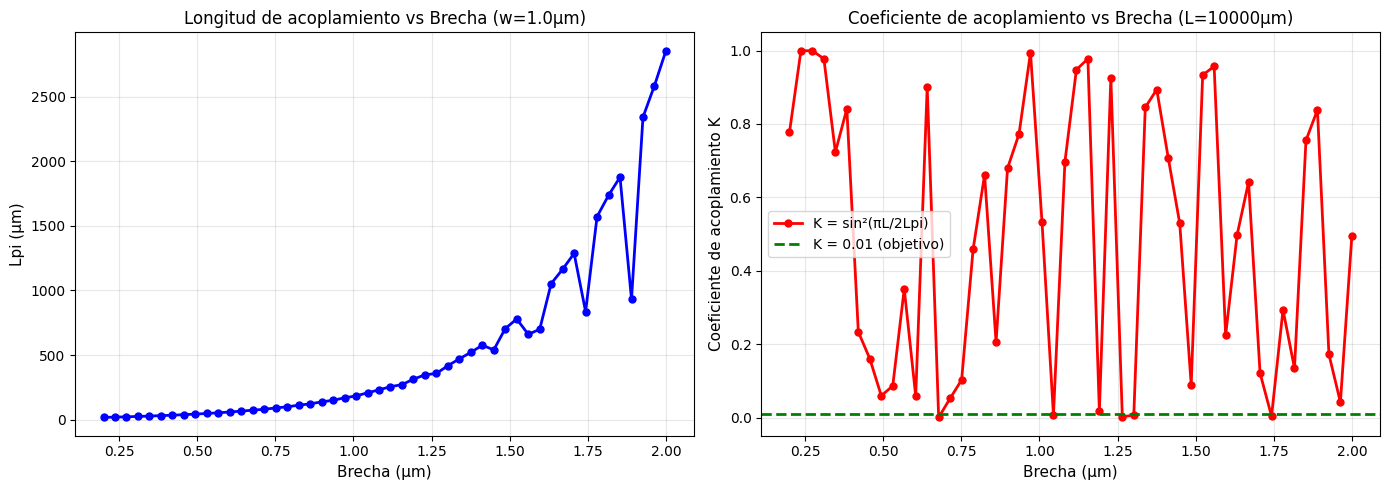


--- Modo TE0 (guía de ondas gravada profundamente) ---
Brecha mínima para K < 0.01: 0.678 µm
Longitud de acoplamiento Lpi: 73.52 µm
Coeficiente de acoplamiento K: 0.000755


In [35]:
# LO.4: Guías de ondas paralelas desacopladas
# Objetivo: K < 0.01 con L = 10 mm para el modo TE0
# w = 1.0 µm, λ = 1.55 µm

lambda_c = 1.55  # µm
L_interaction = 10000  # µm (10 mm)
K_target = 0.01

# Calcula el L_pi requerido para K = 0.01
# K = sin^2(pi*L/(2*Lpi)) = 0.01
# sin(pi*L/(2*Lpi)) = sqrt(0.01) = 0.1
# pi*L/(2*Lpi) = arcsin(0.1)
# Lpi = pi*L/(2*arcsin(0.1))
L_pi_required = np.pi * L_interaction / (2 * np.arcsin(np.sqrt(K_target)))
print(f"L_pi requerido para K = {K_target} con L = {L_interaction} µm: {L_pi_required:.2f} µm")

# Barre brechas para encontrar la requerida
gaps_nm = np.linspace(200, 2000, 50)
gaps_um = gaps_nm / 1000

L_pi_values = []
K_values = []

for gap in gaps_um:
    try:
        test_dc = gt.modes.WaveguideCoupler(
            wavelength=lambda_c,
            core_width=(1.0, 1.0),
            gap=gap,
            slab_thickness=0 * nm,
            core_material='sin',
            clad_material='sio2',
            core_thickness=300 * nm,
            num_modes=4,
            cache_path='.cache/',
            precision='double',
            max_grid_scaling=1.5,
            grid_resolution=20
        )
        test_neff = test_dc.n_eff
        L_pi_te = 0.5 * lambda_c / (test_neff[0].real - test_neff[1].real)
        K = np.sin(np.pi * L_interaction / (2 * L_pi_te))**2
        
        L_pi_values.append(L_pi_te)
        K_values.append(K)
        
        if K <= K_target and K >= K_target - 0.005:
            print(f"Brecha = {gap:.3f} µm: Lpi = {L_pi_te:.2f} µm, K = {K:.6f}")
    except:
        pass

# Grafica resultados
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(gaps_um, L_pi_values, 'b-o', linewidth=2, markersize=5)
ax1.set_xlabel('Brecha (µm)', fontsize=11)
ax1.set_ylabel('Lpi (µm)', fontsize=11)
ax1.set_title('Longitud de acoplamiento vs Brecha (w=1.0µm)', fontsize=12)
ax1.grid(True, alpha=0.3)

ax2.plot(gaps_um, K_values, 'r-o', linewidth=2, markersize=5, label='K = sin²(πL/2Lpi)')
ax2.axhline(y=K_target, color='g', linestyle='--', linewidth=2, label=f'K = {K_target} (objetivo)')
ax2.set_xlabel('Brecha (µm)', fontsize=11)
ax2.set_ylabel('Coeficiente de acoplamiento K', fontsize=11)
ax2.set_title(f'Coeficiente de acoplamiento vs Brecha (L={L_interaction}µm)', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

# Encontrar brecha mínima para K < 0.01
valid_indices = [i for i, k in enumerate(K_values) if k <= K_target]
if valid_indices:
    min_idx = valid_indices[0]
    min_gap = gaps_um[min_idx]
    min_K = K_values[min_idx]
    min_Lpi = L_pi_values[min_idx]
    print(f"\n--- Modo TE0 (guía de ondas gravada profundamente) ---")
    print(f"Brecha mínima para K < {K_target}: {min_gap:.3f} µm")
    print(f"Longitud de acoplamiento Lpi: {min_Lpi:.2f} µm")
    print(f"Coeficiente de acoplamiento K: {min_K:.6f}")

## LO.5. Sección transversal del acoplador de interferencia multimódo (MMI)

### LO.5.1. Definición y simulación de la sección transversal

En GDSFactory - Tidy3d modesolver, podemos simular la sección transversal de un acoplador de interferencia multimódo utilizando la función ya estudiada: [gt.modes.Waveguide()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.Waveguide.html). Los parámetros corresponderán a las dimensiones de la sección del cuerpo MMI. 

In [ ]:
mmi_body_w = 12  
lambda_c = 1550*nm

mmi_body_waveguide = gt.modes.Waveguide(
    # Parámetros geométricos
    core_width=mmi_body_w, # Ancho del cuerpo MMI
    core_thickness=300 * nm, # Altura del cuerpo MMI
    slab_thickness=0 * nm, # Para guías de ondas superficiales - Establece a 0 si es una guía de ondas gravada profundamente.
    # Materiales
    core_material='sin', #  Material de la guía de ondas
    clad_material='sio2', # Material circundante
    # Parámetros del resolvedor de modos
    wavelength=lambda_c, # Longitud de onda a simular
    num_modes=20, # Número de modos objetivo a encontrar - ¡Mayor que antes! Es una sección multimodo
    max_grid_scaling=1.5, # Parámetros de la malla
    grid_resolution=20, # Parámetros de la malla
    cache_path='.cache/', # ¡Importante! Para ahorrar tiempo de simulación, ¡establece tu ruta de caché!
    precision='double',
)

mmi_body_waveguide.n_eff

/home/jfgimloz/CIFOIN_PRACTICA2/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/jfgimloz/CIFOIN_PRACTICA2/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/jfgimloz/CIFOIN_PRACTICA2/cifoin-lab2/.venv/lib/p

2026-03-12 14:58:20.914 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_6c30818797bb0c38.npz.


array([1.6786595 +7.78934672e-05j, 1.67512732+7.81571827e-05j,
       1.66922847+7.86028340e-05j, 1.66094525+7.92401466e-05j,
       1.65025312+8.00839409e-05j, 1.63712124+8.11557006e-05j,
       1.6215135 +8.24863265e-05j, 1.60339058+8.41212350e-05j,
       1.58271457+8.61311110e-05j, 1.5774205 +1.66068730e-04j,
       1.57388942+1.66498915e-04j, 1.56799588+1.67223410e-04j,
       1.55972723+1.68258132e-04j, 1.5594584 +8.86366882e-05j,
       1.54906903+1.69617736e-04j, 1.53601168+1.71243999e-04j,
       1.53362692+9.19569893e-05j, 1.52054265+1.73463904e-04j,
       1.5053405 +9.64080926e-05j, 1.50269423+1.76086361e-04j])

In [ ]:
mmi_body_waveguide.fraction_te

In [ ]:
mmi_body_waveguide.plot_field(mode_index=0 , # Modo a ser graficado
                          field_name='Ex', # Campo a ser graficado
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Sugerencias: Cambia el color del gráfico
                          xlim=(-7, 7), # Establece los límites x e y
                          ylim=(-0.7, 1)
) # 

In [ ]:
mmi_body_waveguide.plot_field(mode_index=1 , # Modo a ser graficado
                          field_name='Ex', # Campo a ser graficado
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Sugerencias: Cambia el color del gráfico
                          xlim=(-7, 7), # Establece los límites x e y
                          ylim=(-0.7, 1)) # 

In [ ]:
mmi_body_waveguide.plot_field(mode_index=7, # Modo a ser graficado
                          field_name='Ex', # Campo a ser graficado
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Sugerencias: Cambia el color del gráfico
                          xlim=(-7, 7), # Establece los límites x e y
                          ylim=(-0.7, 1)) #

#### LO.5.2 Cálculo de longitud (𝐿𝜋)

Con esta información, podríamos calcular nuestra primera estimación para la longitud 𝐿𝜋 del acoplador MMI:

In [19]:
d_n_eff = mmi_body_waveguide.n_eff[0].real -  mmi_body_waveguide.n_eff[1].real

L_pi = 0.5*lambda_c/(d_n_eff)

print (L_pi)

219.41119794418495


## LO.6. Acoplador de interferencia multimódo 2x2

### LO.6.1 Simulación de propagación

Para los acopladores de interferencia multimódo (MMI) debemos confiar en las tablas de diseño que se mostraron en la sesión teórica:

<img src="mmi.png" alt="Tablas de diseño para acopladores MMI" width="600">

Aquí, usarás algunas funciones proporcionadas por nosotros (consulta **0. Importaciones** para más detalles) para simular la propagación en un acoplador direccional 2x2. Por favor, lee todos los comentarios en el código siguiente cuidadosamente y **haz cambios solo en las líneas marcadas con la etiqueta #Student**

In [ ]:
# Flujo de simulación para acopladores MMI
# Define tus parámetros geométricos aquí
mmi_Width = 6.6 # Estudiante. Ancho del cuerpo

m = MMI_EME() # Aquí instancias un acoplador MMI a ser simulado con el algoritmo de expansión de modos propios (EME).
m.MMI_width = mmi_Width
m.MMI_num_modes = 20 # Número de modos a ser calculados. Aquí, cuanto mayor, mejor ya que calcularemos
                    # la propagación basada en la descomposición de modos.

# 1) Calcula los modos del cuerpo MMI - Solo ejecuta cuando un parámetro geométrico cambia. Toma tiempo encontrar los modos.
m.find_all_modes()

# 2) Obtener el L_pi
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/jfgimloz/CIFOIN_PRACTICA2/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  69.03598607255596  µm


/home/jfgimloz/CIFOIN_PRACTICA2/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/690 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9604
Total OUT power: 0.9075
Excess loss [dB] =  0.4217
------------------------
Power over OUTs:  ['0.4675', '0.4399']
Ratio over OUTs ['0.5152', '0.4848']


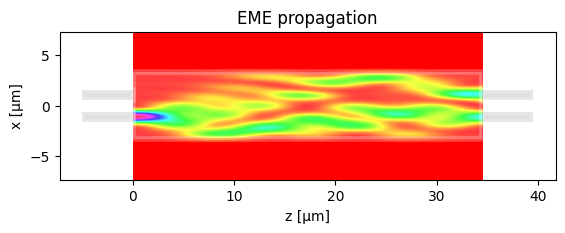

In [ ]:
# ¡IMPORTANTE!
# Si NO cambias el ancho del acoplador MMI
# ni los anchos de las guías de ondas de entrada/salida
# PUEDES EJECUTAR las líneas siguientes tantas veces como desees
# (AHORRA TIEMPO)

# 3) Configura el acoplador MMI
# Número de entrada/salida del acoplador MMI (consulta las diapositivas de clase para el tipo de acoplador MMI)
m.n_IN =  2 # ESTUDIANTE
m.n_OUT = 2 # ESTUDIANTE

# Posiciones de guías de ondas de entrada/salida del acoplador MMI (consulta las diapositivas de clase para el tipo de acoplador MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) # ESTUDIANTE
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) # ESTUDIANTE

# Longitud del acoplador MMI (consulta las diapositivas de clase para el tipo de acoplador MMI)
m.L_MMI = (1/2)*L_pi # ESTUDIANTE

# Ejecuta la propagación
m.propagation()

### LO.6.2. Acoplador de interferencia multimódo 2x2 - Optimización

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/670 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -1.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9524
Total OUT power: 0.8900
Excess loss [dB] =  0.5062
------------------------
Power over OUTs:  ['0.4402', '0.4498']
Ratio over OUTs ['0.4946', '0.5054']


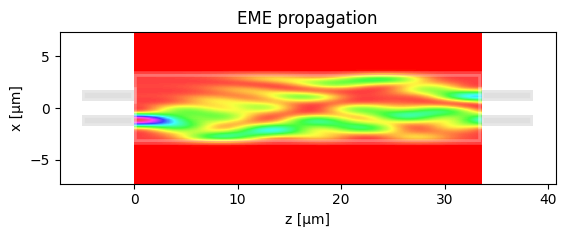

In [ ]:
dy = 0.1
# Posiciones de guías de ondas de entrada/salida del acoplador MMI (consulta las diapositivas de clase para el tipo de acoplador MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy]) # ESTUDIANTE
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy])  # ESTUDIANTE

# Longitud del acoplador MMI (consulta las diapositivas de clase para el tipo de acoplador MMI)
m.dL_MMI = -1  # ESTUDIANTE

# Ejecuta la propagación
m.propagation()

### LO.6.3 Acoplador de interferencia multimódo 2x2 – Optimización (II)

In [ ]:
# Flujo de diseño para acoplador MMI

m = MMI_EME()
m.MMI_width = 6.6   # Ancho del acoplador MMI
m.wg_width_dw = 0.2 # ESTUDIANTE

# 1) Calcula los modos del acoplador MMI
m.find_all_modes()

# 2) Obtener el L_pi
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/jfgimloz/CIFOIN_PRACTICA2/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  69.03598607255869  µm


/home/jfgimloz/CIFOIN_PRACTICA2/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/680 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -0.5000
IO wg width 1.0000
IO wg width increment 0.2000
------------------------
Total power IN coupled 0.9646
Total OUT power: 0.9262
Excess loss [dB] =  0.3330
------------------------
Power over OUTs:  ['0.4682', '0.4580']
Ratio over OUTs ['0.5055', '0.4945']


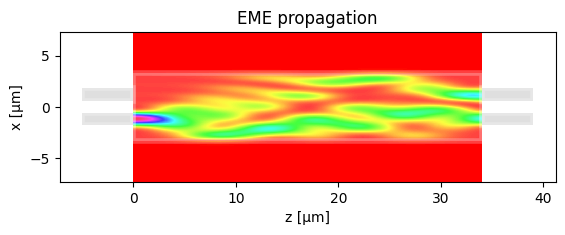

In [ ]:
# 3) Configura el acoplador MMI
# Número de entrada/salida del acoplador MMI (consulta las diapositivas de clase para el tipo de acoplador MMI)
m.n_IN = 2 # ESTUDIANTE
m.n_OUT = 2 # ESTUDIANTE

dy = 0.1
# Posiciones de guías de ondas de entrada/salida del acoplador MMI (consulta las diapositivas de clase para el tipo de acoplador MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy]) # ESTUDIANTE
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy])  # ESTUDIANTE

# Longitud del acoplador MMI (consulta las diapositivas de clase para el tipo de acoplador MMI)
m.L_MMI = (1/2)*L_pi  # ESTUDIANTE
m.dL_MMI = -0.5 # ESTUDIANTE

# Ejecuta la propagación
m.propagation()

## LO.7. Acoplador de interferencia multimódo 1x4

Repite el procedimiento de diseño explicado para el acoplador 2x2 para diseñar un acoplador MMI 1x4. Considera:
- Selecciona un ancho de cuerpo MMI adecuado, teniendo en cuenta que ahora debes asignar 4 guías de ondas en la salida.
- Minimiza las pérdidas y el desbalance de salida del acoplador MMI. 

=== 1x4 MMI Coupler Design ===
MMI Body Width: 13.2 µm
Number of outputs: 4


/home/jfgimloz/CIFOIN_PRACTICA2/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi = 263.95 µm

--- 1x4 MMI Coupler Configuration (Design 1) ---


/home/jfgimloz/CIFOIN_PRACTICA2/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/14 [00:00<?, ?it/s]

  0%|          | 0/3959 [00:00<?, ?it/s]

------- Pameters -------
MMI length 197.9627
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9480
Total OUT power: 0.2471
Excess loss [dB] =  6.0721
------------------------
Power over OUTs:  ['0.0039', '0.1196', '0.1196', '0.0039']
Ratio over OUTs ['0.0159', '0.4841', '0.4841', '0.0159']


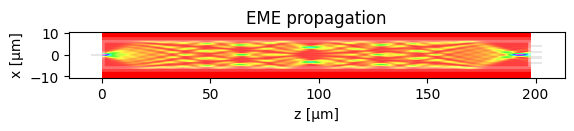

In [ ]:
# LO.7: Diseño del acoplador de interferencia multimódo 1x4

# Para un acoplador 1x4, necesitamos asignar 4 guías de ondas de salida
# Espaciado típico de guías de ondas: ancho 1.2 µm + brecha 0.6 µm entre centros ≈ 1.8 µm por guía de ondas
# Para 4 guías de ondas: al menos 4*1.8 = 7.2 µm, pero usaremos un cuerpo MMI más grande

mmi_Width_1x4 = 13.2  # Ancho adecuado para 4 guías de ondas (1.2 µm cada una + brechas)

print("=== Diseño del acoplador MMI 1x4 ===")
print(f"Ancho del cuerpo MMI: {mmi_Width_1x4} µm")
print(f"Número de salidas: 4")

m_1x4 = MMI_EME()
m_1x4.MMI_width = mmi_Width_1x4
m_1x4.MMI_num_modes = 25  # Número más alto de modos para acoplador 1x4

# 1) Calcula los modos del cuerpo MMI
m_1x4.find_all_modes()

# 2) Obtener L_pi
L_pi_1x4 = m_1x4.get_L_pi()
print(f"L_pi = {L_pi_1x4:.2f} µm")

# 3) Configura el acoplador MMI 1x4
# Basado en tablas de diseño, para acoplador 1x4:
# - Longitud = (3/4) * Lpi para distribución de potencia igual
m_1x4.n_IN = 1   # 1 entrada
m_1x4.n_OUT = 4  # 4 salidas

# Posiciones para 4 guías de ondas de salida (distribuidas simétricamente)
output_spacing = mmi_Width_1x4 / 5  # Espacio entre guías de ondas
m_1x4.OUT_WVG_positions = np.array([-1.5, -0.5, 0.5, 1.5]) * output_spacing

# Posición de entrada (centro)
m_1x4.IN_WVG_positions = np.array([0])

# Longitud del acoplador MMI para acoplador 1x4
m_1x4.L_MMI = (3/4) * L_pi_1x4

# Ejecuta la propagación
print("\n--- Configuración del acoplador MMI 1x4 (Diseño 1) ---")
m_1x4.propagation()


## Ejercicios Extra

### E1. Dependencia de la brecha del acoplador direccional

In [ ]:
gap_to_simulate = 600 * nm # ESTUDIANTE. Puedes cambiar manualmente la brecha
                            # o barriendo el parámetro usando un bucle for de Python.

deep_dcoupler_cs = gt.modes.WaveguideCoupler(
    wavelength=wavelength, # Longitud de onda a simular - Debe ser un vector
    core_width=(1.0, 1.0), # Ancho de la guía de ondas
    gap=gap_to_simulate,
    slab_thickness=0 * nm, # Para guías de ondas superficiales - Establece a 0 si es una guía de ondas profundamente grabada.
    core_material='sin', #  Material de la guía de ondas
    clad_material='sio2', # Material circundante
    core_thickness=300 * nm, # Altura de la guía de ondas
    num_modes=4, # Número de modos a encontrar
    cache_path='.cache/', # ¡Importante! Para ahorrar tiempo de simulación, ¡establece tu ruta de caché!
    precision='double',
    max_grid_scaling=1.5, # Parámetros de la malla
    grid_resolution=20 # Parámetros de la malla
)

# ESTUDIANTE. El gráfico va aquí


### E2. Dependencia de la longitud de onda del acoplador direccional

In [ ]:
wavelength = ... # Código ESTUDIANTE aquí

deep_dcoupler_cs = gt.modes.WaveguideCoupler(
    wavelength=wavelength, # Longitud de onda a simular - Debe ser un vector
    core_width=(1.0, 1.0), # Ancho de la guía de ondas
    gap=600 * nm,
    slab_thickness=0 * nm, # Para guías de ondas superficiales - Establece a 0 si es una guía de ondas profundamente grabada.
    core_material='sin', #  Material de la guía de ondas
    clad_material='sio2', # Material circundante
    core_thickness=300 * nm, # Altura de la guía de ondas
    num_modes=4, # Número de modos a encontrar
    cache_path='.cache/', # ¡Importante! Para ahorrar tiempo de simulación, ¡establece tu ruta de caché!
    precision='double',
    max_grid_scaling=1.5, # Parámetros de la malla
    grid_resolution=20 # Parámetros de la malla
)

deep_neff = deep_dcoupler_cs.n_eff
L_pi_TE = ... # Código ESTUDIANTE aquí

plt.figure(figsize=(10, 5))
plt.scatter(wavelength, L_pi_TE,edgecolors='k',facecolors='none',label = '__nolegend__')
plt.plot(wavelength, L_pi_TE,label='Profundo')
plt.xlabel("Longitud de onda (µm)")
plt.ylabel("L_pi")
plt.grid()
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])

2026-03-12 15:03:46.639 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_ab1aa1667946aeed.npz.


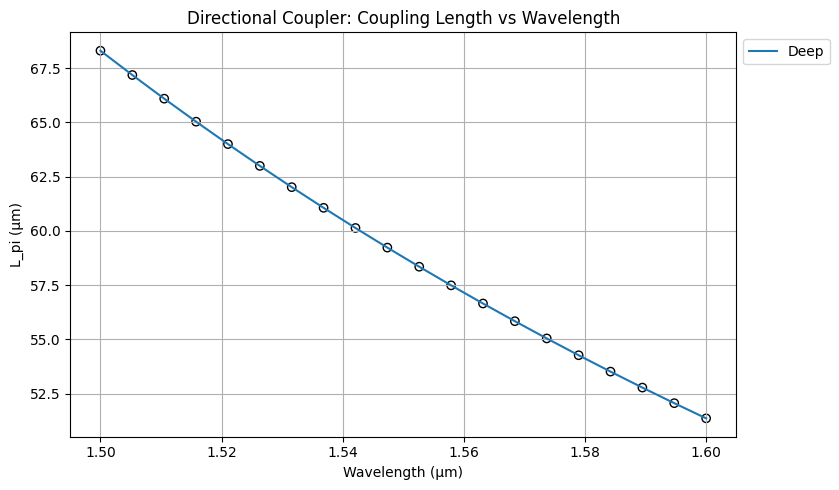

In [ ]:
# E2: Dependencia de la longitud de onda del acoplador direccional

wavelength = np.linspace(1.5, 1.6, 20)  # 1.5 a 1.6 µm

deep_dcoupler_cs = gt.modes.WaveguideCoupler(
    wavelength=wavelength, # Longitud de onda a simular - Debe ser un vector
    core_width=(1.0, 1.0), # Ancho de la guía de ondas
    gap=600 * nm,
    slab_thickness=0 * nm, # Para guías de ondas superficiales - Establece a 0 si es una guía de ondas profundamente grabada.
    core_material='sin', #  Material de la guía de ondas
    clad_material='sio2', # Material circundante
    core_thickness=300 * nm, # Altura de la guía de ondas
    num_modes=4, # Número de modos a encontrar
    cache_path='.cache/', # ¡Importante! Para ahorrar tiempo de simulación, ¡establece tu ruta de caché!
    precision='double',
    max_grid_scaling=1.5, # Parámetros de la malla
    grid_resolution=20 # Parámetros de la malla
)

deep_neff = deep_dcoupler_cs.n_eff
# La forma de deep_neff es (20 longitudes de onda, 4 modos)
L_pi_TE = 0.5 * wavelength / (deep_neff[:, 0].real - deep_neff[:, 1].real)

plt.figure(figsize=(10, 5))
plt.scatter(wavelength, L_pi_TE,edgecolors='k',facecolors='none',label = '__nolegend__')
plt.plot(wavelength, L_pi_TE,label='Profundo')
plt.xlabel("Longitud de onda (µm)")
plt.ylabel("L_pi (µm)")
plt.title("Acoplador direccional: Longitud de acoplamiento vs Longitud de onda")
plt.grid()
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

### E3. Dependencia de la longitud de onda del acoplador MMI

In [ ]:
mmi_body_w = 6.6 
lambda_c = ... # Código ESTUDIANTE aquí.

mmi_body_waveguide = gt.modes.Waveguide(
    # Parámetros geométricos
    core_width=mmi_body_w, # Ancho del cuerpo MMI
    core_thickness=300 * nm, # Altura del cuerpo MMI
    slab_thickness=0 * nm, # Para guías de ondas superficiales - Establece a 0 si es una guía de ondas profundamente grabada.
    # Materiales
    core_material='sin', #  Material de la guía de ondas
    clad_material='sio2', # Material circundante
    # Parámetros del resolvedor de modos
    wavelength=lambda_c, # Longitud de onda a simular
    num_modes=15, # Número de modos objetivo a encontrar - ¡Mayor que antes! Es una sección multimodo
    max_grid_scaling=1.5, # Parámetros de la malla
    grid_resolution=20, # Parámetros de la malla
    cache_path='.cache/', # ¡Importante! Para ahorrar tiempo de simulación, ¡establece tu ruta de caché!
    precision='double',
)

d_n_eff = mmi_body_waveguide.n_eff[0].real -  mmi_body_waveguide.n_eff[1].real

L_pi = ... # Código ESTUDIANTE aquí

# Gráfico ESTUDIANTE aquí. 

ValidationError: 1 validation error for Waveguide
wavelength
  float() argument must be a string or a real number, not 'ellipsis' (type=type_error)

/home/jfgimloz/CIFOIN_PRACTICA2/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/jfgimloz/CIFOIN_PRACTICA2/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/jfgimloz/CIFOIN_PRACTICA2/cifoin-lab2/.venv/lib/p

15:10:30 CET WARNING: Mode '13' appears to undergo a discontinuous change       
             between frequencies '190777018727272.72' and '191648146666666.66'  
             (overlap: '0.89').                                                 

             WARNING: Mode '14' appears to undergo a discontinuous change       
             between frequencies '190777018727272.72' and '191648146666666.66'  
             (overlap: '0.89').                                                 

15:10:31 CET WARNING: Mode field at frequency index 0, mode index 14 does not   
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 1, mode index 14 does not   
             decay at the plane boundaries.                                     

...

             WARNING: Mode field at frequency index 13, mode index 13 does not  
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 13, mode index 14 does not  
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 14, mode index 13 does not  
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 14, mode index 14 does not  
             decay at the plane boundaries.                                     

2026-03-12 15:10:34.196 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_9a84ec86ddf79b0a.npz.


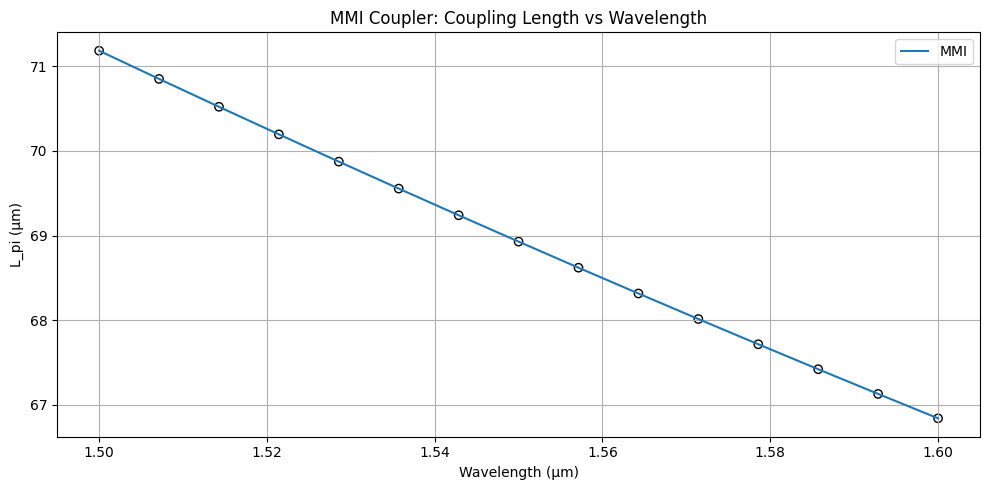

In [ ]:
# E3: Dependencia de la longitud de onda del acoplador MMI

mmi_body_w = 6.6 
lambda_c = np.linspace(1.5, 1.6, 15)

mmi_body_waveguide = gt.modes.Waveguide(
    # Parámetros geométricos
    core_width=mmi_body_w, # Ancho del cuerpo MMI
    core_thickness=300 * nm, # Altura del cuerpo MMI
    slab_thickness=0 * nm, # Para guías de ondas superficiales - Establece a 0 si es una guía de ondas profundamente grabada.
    # Materiales
    core_material='sin', #  Material de la guía de ondas
    clad_material='sio2', # Material circundante
    # Parámetros del resolvedor de modos
    wavelength=lambda_c, # Longitud de onda a simular
    num_modes=15, # Número de modos objetivo a encontrar - ¡Mayor que antes! Es una sección multimodo
    max_grid_scaling=1.5, # Parámetros de la malla
    grid_resolution=20, # Parámetros de la malla
    cache_path='.cache/', # ¡Importante! Para ahorrar tiempo de simulación, ¡establece tu ruta de caché!
    precision='double',
)

d_n_eff = mmi_body_waveguide.n_eff[:, 0].real - mmi_body_waveguide.n_eff[:, 1].real

L_pi = 0.5 * lambda_c / d_n_eff

plt.figure(figsize=(10, 5))
plt.scatter(lambda_c, L_pi, edgecolors='k', facecolors='none')
plt.plot(lambda_c, L_pi, label='MMI')
plt.xlabel("Longitud de onda (µm)")
plt.ylabel("L_pi (µm)")
plt.title("Acoplador MMI: Longitud de acoplamiento vs Longitud de onda")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

### E4. Dependencia del ancho del cuerpo del acoplador MMI

In [ ]:
lambda_c = 1.55

mmi_body_w = 6.6 # ESTUDIANTE. Puedes cambiar manualmente el ancho del cuerpo
                 # o barriendo el parámetro usando un bucle for de Python.

mmi_body_waveguide = gt.modes.Waveguide(
    # Parámetros geométricos
    core_width=mmi_body_w, # Ancho del cuerpo MMI
    core_thickness=300 * nm, # Altura del cuerpo MMI
    slab_thickness=0 * nm, # Para guías de ondas superficiales - Establece a 0 si es una guía de ondas profundamente grabada.
    # Materiales
    core_material='sin', #  Material de la guía de ondas
    clad_material='sio2', # Material circundante
    # Parámetros del resolvedor de modos
    wavelength=lambda_c, # Longitud de onda a simular
    num_modes=15, # Número de modos objetivo a encontrar - ¡Mayor que antes! Es una sección multimodo
    max_grid_scaling=1.5, # Parámetros de la malla
    grid_resolution=20, # Parámetros de la malla
    cache_path='.cache/', # ¡Importante! Para ahorrar tiempo de simulación, ¡establece tu ruta de caché!
    precision='double',
)

d_n_eff = mmi_body_waveguide.n_eff[0].real -  mmi_body_waveguide.n_eff[1].real

L_pi = ... # Código ESTUDIANTE aquí

# Gráfico ESTUDIANTE aquí. 

/home/jfgimloz/CIFOIN_PRACTICA2/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/jfgimloz/CIFOIN_PRACTICA2/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/jfgimloz/CIFOIN_PRACTICA2/cifoin-lab2/.venv/lib/p

15:12:53 CET WARNING: Mode field at frequency index 0, mode index 14 does not   
             decay at the plane boundaries.                                     

2026-03-12 15:12:53.397 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_cc174b674ffff0ec.npz.


# Calificación
- LO1 - 0.5 Punto
- LO2 - 1 Punto
- LO3 - 1 Punto
- LO4 - 1 Punto
- LO5 - 0.5 Punto
- LO6 - 1 Punto
- LO7 - 2 Puntos
- E1-E4 - Hasta 3 Puntos